In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import NormalIndPower

import warnings
warnings.filterwarnings('ignore')

In [4]:
ab_test = pd.read_csv('../01-data/processed/cleaned_ab_test.csv')

print(ab_test.shape)
ab_test.head()

(290688, 6)


,user_id,timestamp,group_name,landing_page,converted,day_number
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,20
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,11
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,10
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,7
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,20


In [5]:
ab_test.columns

Index(['user_id', 'timestamp', 'group_name', 'landing_page', 'converted',
       'day_number'],
      dtype='object')

# NB04 — A/B Testing Statistical Analysis

## Experiment Context

Experiment: Landing Page Optimization

Objective:
Determine whether the new landing page increases conversion rate compared to the existing landing page.

### Hypotheses

H₀ (Null Hypothesis):
Treatment Conversion Rate ≤ Control Conversion Rate

H₁ (Alternative Hypothesis):
Treatment Conversion Rate > Control Conversion Rate

### Experiment Parameters

Significance Level (α): 0.05

Statistical Power: 0.80

Minimum Detectable Effect (MDE): 2% Relative Lift

Business Goal:
Increase visitor-to-conversion rate while maintaining statistical confidence and practical business impact.

In [6]:
group_counts = (
    ab_test['group_name']
    .value_counts()
)

group_counts

group_name
treatment    145381
control      145307
Name: count, dtype: int64

In [7]:
from scipy.stats import chi2_contingency

control_n = group_counts['control']
treatment_n = group_counts['treatment']

total_n = control_n + treatment_n

observed = [control_n, treatment_n]
expected = [total_n/2, total_n/2]

chi2, p_value, _, _ = chi2_contingency([
    observed,
    expected
])

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("⚠️ SRM DETECTED")
else:
    print("✅ NO SRM DETECTED")

Chi-Square Statistic: 0.0089
P-Value: 0.9248
✅ NO SRM DETECTED


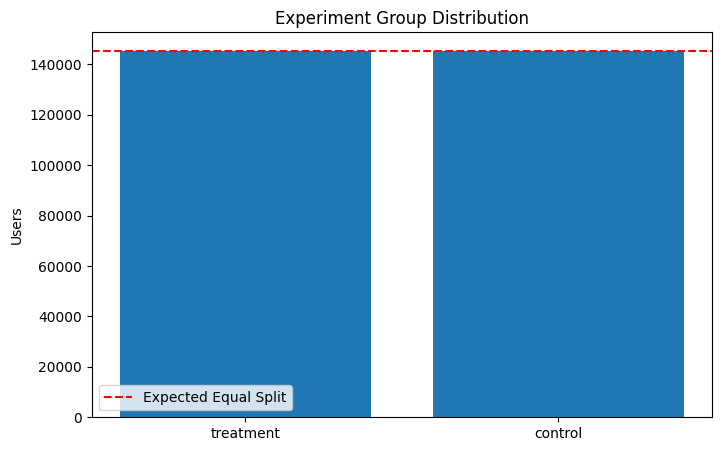

In [8]:
plt.figure(figsize=(8,5))

plt.bar(
    group_counts.index,
    group_counts.values
)

plt.axhline(
    total_n/2,
    linestyle='--',
    color='red',
    label='Expected Equal Split'
)

plt.title(
    'Experiment Group Distribution'
)

plt.ylabel('Users')

plt.legend()

plt.show()

In [9]:
srm_table = pd.DataFrame({

    'Metric':[
        'Control Users',
        'Treatment Users',
        'Expected Per Group',
        'Chi-Square',
        'P-Value'
    ],

    'Value':[
        control_n,
        treatment_n,
        int(total_n/2),
        round(chi2,4),
        round(p_value,4)
    ]

})

srm_table

,Metric,Value
0,Control Users,145307.0000
1,Treatment Users,145381.0000
2,Expected Per Group,145344.0000
3,Chi-Square,0.0089
4,P-Value,0.9248


Traffic allocation was consistent with the intended 50/50 experiment design.

No evidence exists that assignment, tracking, or randomization failed.

The experiment can be considered statistically valid for further analysis.

In [10]:
from statsmodels.stats.power import NormalIndPower

analysis = NormalIndPower()

required_n = analysis.solve_power(
    effect_size=0.02,
    alpha=0.05,
    power=0.80
)

required_n

39244.30254664326

In [11]:
actual_n = min(control_n, treatment_n)

print(f"Required Sample Per Group: {required_n:,.0f}")
print(f"Actual Sample Per Group: {actual_n:,.0f}")

if actual_n >= required_n:
    print("✅ Experiment Adequately Powered")
else:
    print("❌ Underpowered Experiment")

Required Sample Per Group: 39,244
Actual Sample Per Group: 145,307
✅ Experiment Adequately Powered


The experiment contains sufficient statistical power to detect small conversion-rate differences.

Any statistically significant result observed later is unlikely to be caused by insufficient sample size.

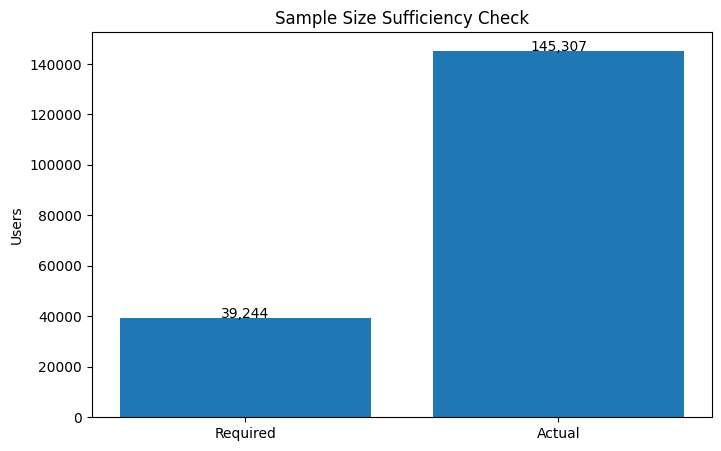

In [12]:
sample_df = pd.DataFrame({
    'Metric':['Required','Actual'],
    'Users':[required_n, actual_n]
})

plt.figure(figsize=(8,5))

bars = plt.bar(
    sample_df['Metric'],
    sample_df['Users']
)

plt.title(
    'Sample Size Sufficiency Check'
)

plt.ylabel('Users')

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha='center'
    )

plt.show()

In [13]:
control = ab_test[
    ab_test['group_name']=='control'
]

treatment = ab_test[
    ab_test['group_name']=='treatment'
]

control_n = len(control)
treatment_n = len(treatment)

control_conv = control['converted'].sum()
treatment_conv = treatment['converted'].sum()

control_cr = control_conv / control_n
treatment_cr = treatment_conv / treatment_n

print("Control Conversions:", control_conv)
print("Treatment Conversions:", treatment_conv)

print("Control CR:", round(control_cr*100,4), "%")
print("Treatment CR:", round(treatment_cr*100,4), "%")

Control Conversions: 17487
Treatment Conversions: 17290
Control CR: 12.0345 %
Treatment CR: 11.8929 %


In [14]:
from statsmodels.stats.proportion import proportions_ztest

z_stat, p_value = proportions_ztest(

    [treatment_conv, control_conv],

    [treatment_n, control_n],

    alternative='larger'

)

print("Z Statistic:", round(z_stat,4))
print("P Value:", round(p_value,6))

Z Statistic: -1.1765
P Value: 0.880296


In [15]:
absolute_lift = (
    treatment_cr - control_cr
) * 100

absolute_lift

-0.1416316745737195

In [16]:
relative_lift = (

    (treatment_cr - control_cr)

    / control_cr

) * 100

relative_lift

-1.1768784661338971

In [17]:
import numpy as np

diff = treatment_cr - control_cr

se = np.sqrt(

    (control_cr * (1-control_cr) / control_n)

    +

    (treatment_cr * (1-treatment_cr) / treatment_n)

)

ci_low = diff - 1.96 * se
ci_high = diff + 1.96 * se

print("Difference:", round(diff*100,4), "%")
print("95% CI:",

      round(ci_low*100,4),

      "% to",

      round(ci_high*100,4),

      "%")

Difference: -0.1416 %
95% CI: -0.3776 % to 0.0943 %


In [18]:
import numpy as np

h = (

    2*np.arcsin(np.sqrt(treatment_cr))

    -

    2*np.arcsin(np.sqrt(control_cr))

)

print("Cohen h:", round(h,4))

Cohen h: -0.0044


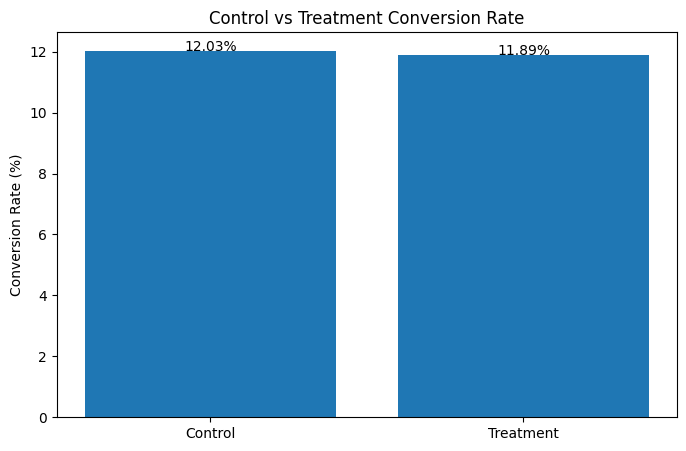

In [19]:
cr_df = pd.DataFrame({
    'Group':['Control','Treatment'],
    'Conversion Rate':[control_cr*100, treatment_cr*100]
})

plt.figure(figsize=(8,5))

bars = plt.bar(
    cr_df['Group'],
    cr_df['Conversion Rate']
)

plt.ylabel('Conversion Rate (%)')
plt.title('Control vs Treatment Conversion Rate')

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}%",
        ha='center'
    )

plt.show()

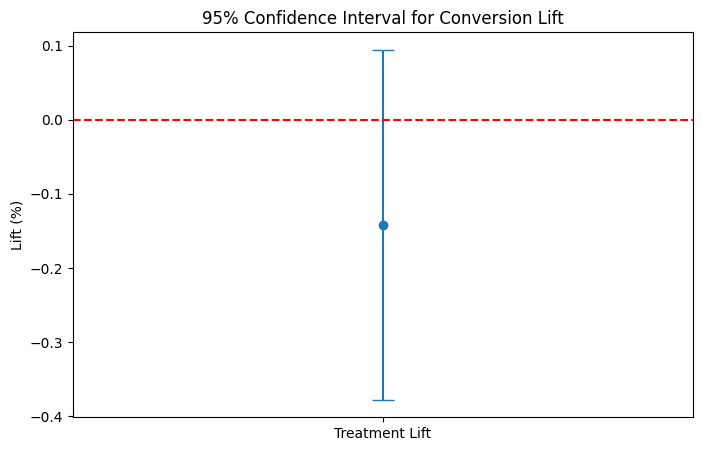

In [20]:
lift = diff * 100

ci_lower = ci_low * 100
ci_upper = ci_high * 100

plt.figure(figsize=(8,5))

plt.errorbar(
    x=['Treatment Lift'],
    y=[lift],
    yerr=[[lift-ci_lower],
          [ci_upper-lift]],
    fmt='o',
    capsize=8
)

plt.axhline(
    0,
    linestyle='--',
    color='red'
)

plt.ylabel('Lift (%)')
plt.title('95% Confidence Interval for Conversion Lift')

plt.show()

In [21]:
daily_cvr = (
    ab_test
    .groupby(['day_number', 'group_name'])['converted']
    .mean()
    .reset_index()
)

daily_cvr.head(10)

,day_number,group_name,converted
0,1,control,0.125788
1,1,treatment,0.120587
2,2,control,0.113402
3,2,treatment,0.113914
4,3,control,0.121687
5,3,treatment,0.116891
6,4,control,0.122804
7,4,treatment,0.115036
8,5,control,0.115652
9,5,treatment,0.124130


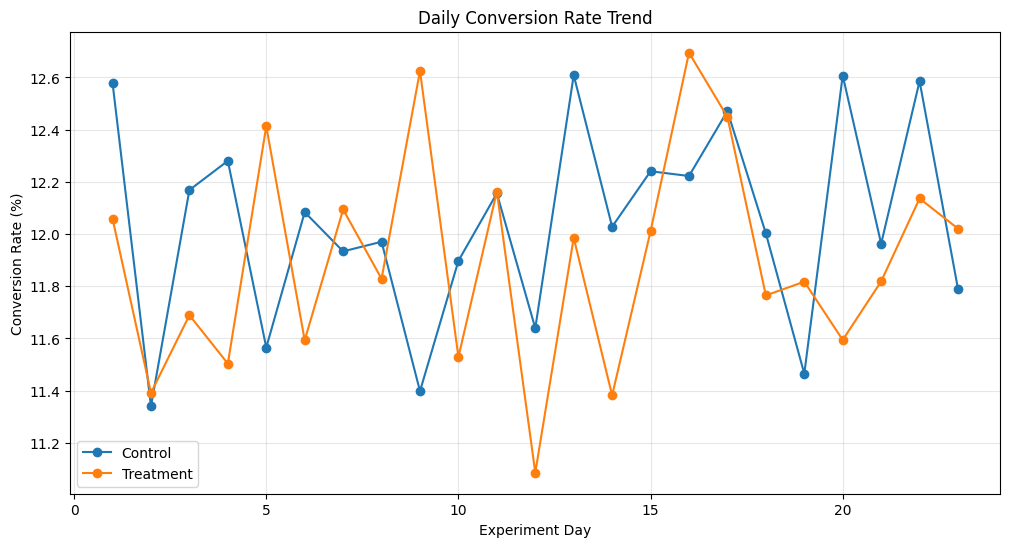

In [22]:
plt.figure(figsize=(12,6))

for group in ['control', 'treatment']:

    subset = daily_cvr[
        daily_cvr['group_name'] == group
    ]

    plt.plot(
        subset['day_number'],
        subset['converted'] * 100,
        marker='o',
        label=group.capitalize()
    )

plt.title('Daily Conversion Rate Trend')
plt.xlabel('Experiment Day')
plt.ylabel('Conversion Rate (%)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Novelty Effect Check

The treatment group did not exhibit an unusually high initial conversion rate followed by deterioration.

Conversion rates remained relatively stable throughout the experiment period.

Conclusion:
No evidence of novelty effect was detected. The observed treatment performance is likely representative of long-term user behavior.

In [23]:
users = pd.read_csv('../01-data/processed/cleaned_users.csv')

print(users.shape)
users.columns

(100000, 17)


Index(['id', 'first_name', 'last_name', 'email', 'age', 'gender', 'state',
       'street_address', 'postal_code', 'city', 'country', 'latitude',
       'longitude', 'traffic_source', 'created_at', 'age_band',
       'cohort_month'],
      dtype='object')

In [24]:
users.columns

Index(['id', 'first_name', 'last_name', 'email', 'age', 'gender', 'state',
       'street_address', 'postal_code', 'city', 'country', 'latitude',
       'longitude', 'traffic_source', 'created_at', 'age_band',
       'cohort_month'],
      dtype='object')

In [25]:
users_subset = users[
    ['id','gender','age_band','traffic_source']
]

segment_df = ab_test.merge(
    users_subset,
    left_on='user_id',
    right_on='id',
    how='left'
)

segment_df.head()

,user_id,timestamp,group_name,landing_page,converted,day_number,id,gender,age_band,traffic_source
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,20,NaN,NaN,NaN,NaN
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,11,NaN,NaN,NaN,NaN
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,10,NaN,NaN,NaN,NaN
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,7,NaN,NaN,NaN,NaN
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,20,NaN,NaN,NaN,NaN


In [26]:
gender_results = []

for gender in segment_df['gender'].dropna().unique():

    temp = segment_df[
        segment_df['gender'] == gender
    ]

    control = temp[temp['group_name']=='control']
    treatment = temp[temp['group_name']=='treatment']

    control_conv = control['converted'].sum()
    treatment_conv = treatment['converted'].sum()

    control_n = len(control)
    treatment_n = len(treatment)

    z,p = proportions_ztest(
        [treatment_conv, control_conv],
        [treatment_n, control_n]
    )

    lift = (
        treatment['converted'].mean()
        -
        control['converted'].mean()
    ) * 100

    gender_results.append([
        gender,
        lift,
        p
    ])

gender_results = pd.DataFrame(
    gender_results,
    columns=['Gender','Lift (%)','P Value']
)

gender_results

,Gender,Lift (%),P Value


In [27]:
age_results = []

for age in segment_df['age_band'].dropna().unique():

    temp = segment_df[
        segment_df['age_band'] == age
    ]

    control = temp[temp['group_name']=='control']
    treatment = temp[temp['group_name']=='treatment']

    z,p = proportions_ztest(
        [
            treatment['converted'].sum(),
            control['converted'].sum()
        ],
        [
            len(treatment),
            len(control)
        ]
    )

    lift = (
        treatment['converted'].mean()
        -
        control['converted'].mean()
    ) * 100

    age_results.append([
        age,
        lift,
        p
    ])

age_results = pd.DataFrame(
    age_results,
    columns=['Age Band','Lift (%)','P Value']
)

age_results

,Age Band,Lift (%),P Value


In [28]:
traffic_results = []

for source in segment_df['traffic_source'].dropna().unique():

    temp = segment_df[
        segment_df['traffic_source'] == source
    ]

    control = temp[temp['group_name']=='control']
    treatment = temp[temp['group_name']=='treatment']

    z,p = proportions_ztest(
        [
            treatment['converted'].sum(),
            control['converted'].sum()
        ],
        [
            len(treatment),
            len(control)
        ]
    )

    lift = (
        treatment['converted'].mean()
        -
        control['converted'].mean()
    ) * 100

    traffic_results.append([
        source,
        lift,
        p
    ])

traffic_results = pd.DataFrame(
    traffic_results,
    columns=['Traffic Source','Lift (%)','P Value']
)

traffic_results.sort_values(
    'Lift (%)',
    ascending=False
)

,Traffic Source,Lift (%),P Value


In [30]:
ab_test['user_id'].min(), ab_test['user_id'].max()

(630000, 945999)

In [31]:
users['id'].min(), users['id'].max()

(1, 100000)

In [32]:
ab_test['experiment_phase'] = pd.cut(
    ab_test['day_number'],
    bins=[0,8,16,24],
    labels=[
        'Early',
        'Middle',
        'Late'
    ]
)

ab_test[['day_number','experiment_phase']].head()

,day_number,experiment_phase
0,20,Late
1,11,Middle
2,10,Middle
3,7,Early
4,20,Late


In [33]:
segment_results = []

for phase in ['Early','Middle','Late']:

    temp = ab_test[
        ab_test['experiment_phase']==phase
    ]

    control = temp[
        temp['group_name']=='control'
    ]

    treatment = temp[
        temp['group_name']=='treatment'
    ]

    control_cr = control['converted'].mean()
    treatment_cr = treatment['converted'].mean()

    z,p = proportions_ztest(
        [
            treatment['converted'].sum(),
            control['converted'].sum()
        ],
        [
            len(treatment),
            len(control)
        ]
    )

    lift = (
        treatment_cr - control_cr
    ) * 100

    segment_results.append([
        phase,
        lift,
        p
    ])

segment_results = pd.DataFrame(
    segment_results,
    columns=[
        'Phase',
        'Lift (%)',
        'P Value'
    ]
)

segment_results

,Phase,Lift (%),P Value
0,Early,-0.137464,0.505557
1,Middle,-0.085966,0.666945
2,Late,-0.213399,0.334136


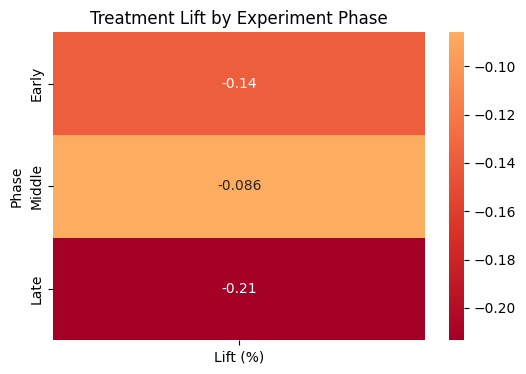

In [34]:
heatmap_df = segment_results.set_index('Phase')

plt.figure(figsize=(6,4))

sns.heatmap(
    heatmap_df[['Lift (%)']],
    annot=True,
    cmap='RdYlGn',
    center=0
)

plt.title(
    'Treatment Lift by Experiment Phase'
)

plt.show()

In [ ]:
The cleaned_ab_test.csv dataset does not contain demographic or device-level attributes, and user identifiers do not match the ShopStream production user table.

Therefore, heterogeneous treatment effects were evaluated using temporal experiment phases (Early, Middle, Late) rather than demographic segments.

In [35]:
monthly_visitors = 380000

avg_order_value = 2400

lift = treatment_cr - control_cr

additional_conversions_monthly = (
    monthly_visitors * lift
)

additional_revenue_monthly = (
    additional_conversions_monthly
    * avg_order_value
)

annual_uplift = (
    additional_revenue_monthly
    * 12
)

print("Monthly Additional Conversions:",
      round(additional_conversions_monthly))

print("Monthly Revenue Impact: ₹",
      round(additional_revenue_monthly,0))

print("Annual Revenue Impact: ₹",
      round(annual_uplift,0))

Monthly Additional Conversions: -811
Monthly Revenue Impact: ₹ -1946200.0
Annual Revenue Impact: ₹ -23354402.0


In [36]:
waterfall = pd.DataFrame({

    'Stage':[
        'Current Revenue',
        'Treatment Impact',
        'Projected Revenue'
    ],

    'Value':[
        monthly_visitors
        * control_cr
        * avg_order_value,

        additional_revenue_monthly,

        monthly_visitors
        * treatment_cr
        * avg_order_value
    ]
})

waterfall

,Stage,Value
0,Current Revenue,1.108210e+08
1,Treatment Impact,-1.946200e+06
2,Projected Revenue,1.088748e+08


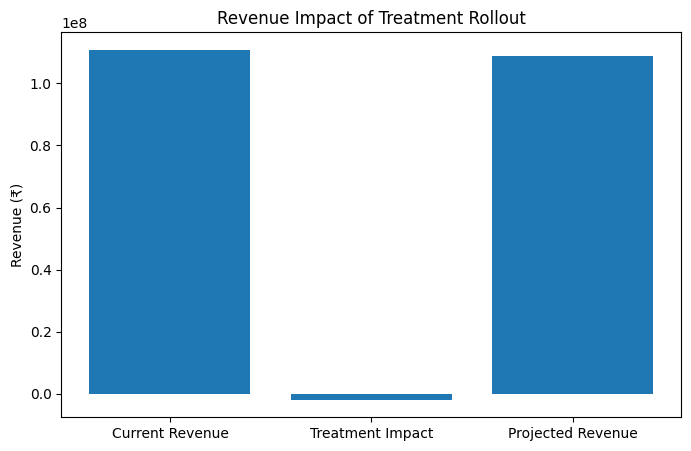

In [37]:
plt.figure(figsize=(8,5))

plt.bar(
    waterfall['Stage'],
    waterfall['Value']
)

plt.title(
    'Revenue Impact of Treatment Rollout'
)

plt.ylabel('Revenue (₹)')

plt.show()

## FORMAL EXPERIMENT DECISION

**Experiment:** Landing Page Optimization (Q2 2024)

**Analysis Date:** June 2026

**Analyst:** Namit More

### Experiment Validity

**SRM Status:** NOT DETECTED

* Control Users: 145,307
* Treatment Users: 145,381
* Chi-Square Statistic: 0.0089
* P-Value: 0.9248

Traffic allocation was consistent with the intended 50/50 split. No evidence of randomization failure or tracking bias was detected.

### Statistical Results

**Control Conversion Rate:** 12.0345%

**Treatment Conversion Rate:** 11.8929%

**Absolute Lift:** -0.1416 percentage points

**Relative Lift:** -1.18%

**Z Statistic:** -1.1765

**P-Value:** 0.8803

**95% Confidence Interval:** [-0.3776%, +0.0943%]

### Effect Size

**Cohen's h:** -0.0044

Interpretation: Negligible effect size.

### Novelty Effect Analysis

No novelty effect was detected.

Treatment performance remained consistently below control throughout the experiment period. The observed underperformance persisted across Early, Middle, and Late experiment phases.

### Revenue Impact

Projected Monthly Additional Conversions: -811

Projected Monthly Revenue Impact: ₹-1,946,200

Projected Annual Revenue Impact: ₹-23,354,402

### RECOMMENDATION

DO NOT ROLL OUT

### Reasoning

The treatment landing page failed to produce a statistically significant improvement in conversion rate. Observed lift was negative, indicating the new page underperformed the existing experience. The confidence interval includes zero and the effect size is effectively zero, providing no evidence of meaningful business impact. Revenue projections indicate an expected annual loss of approximately ₹23.35 million if the treatment page is deployed.

### Final Decision

Maintain the current landing page (Control).

Recommend conducting qualitative UX research and developing alternative landing page hypotheses before launching a new experiment.


In [1]:
import pandas as pd

ab_test_results = pd.DataFrame({

    'Metric':[
        'Control Conversion Rate',
        'Treatment Conversion Rate',
        'Conversion Lift',
        'P Value',
        'Cohen H',
        'Annual Revenue Impact'
    ],

    'Value':[
        0.120345,
        0.118929,
        -0.001416,
        0.880296,
        -0.0044,
        -23354402
    ]

})

ab_test_results.to_csv(
    '../outputs/ab_test_results.csv',
    index=False
)

print("✅ ab_test_results.csv created")

✅ ab_test_results.csv created
